In [1]:
here::i_am("atac/archR/dimensionality_reduction/cells/archR_dimensionality_reduction.R")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(ArchR))

######################
## Define arguments ##
######################

# p <- ArgumentParser(description='')
# p$add_argument('--metadata',        type="character",                               help='Cell metadata file')
# p$add_argument('--matrix',          type="character",  default="PeakMatrix",   help='Matrix to use')
# # p$add_argument('--samples',         type="character",                nargs='+',     help='Samples')
# p$add_argument('--stages',       type="character",  default="all",  nargs='+',  help='Stages to plot')
# p$add_argument('--remove_ExE_cells', action="store_true",                                 help='Remove ExE cells?')
# p$add_argument('--nfeatures',       type="integer",    default=1000,               help='Number of features')
# p$add_argument('--ndims',           type="integer",    default=30,                  help='Number of LSI dimensions')
# p$add_argument('--batch.variable',  type="character",                               help='Metadata column to apply batch correction on')
# p$add_argument('--batch.method',    type="character",  default="MNN",               help='Batch correctin method ("Harmony" or "MNN")')
# p$add_argument('--n_neighbors',     type="integer",    default=30,   nargs='+',     help='(UMAP) Number of neighbours')
# p$add_argument('--min_dist',        type="double",     default=0.3,  nargs='+',     help='(UMAP) Minimum distance')
# p$add_argument('--colour_by',       type="character",  nargs='+',  help='Metadata columns to colour the UMAP by')
# p$add_argument('--seed',            type="integer",    default=42,                  help='Random seed')
# p$add_argument('--outdir',          type="character",                               help='Output directory')

# args <- p$parse_args(commandArgs(TRUE))

## START TEST ##
args <- list()
args$metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/archR/qc/sample_metadata_after_qc.txt.gz"
args$nfeatures <- 15000
args$matrix <- "PeakMatrix"
args$stages = 'all'
args$ndims <- 25
args$seed <- 42
args$n_neighbors <- 25
args$min_dist <- 0.3
args$colour_by <- c("celltype")
args$vars_to_regress <- c("nFeature_RNA","mitochondrial_percent_RNA")
args$remove_ExE_cells = FALSE
# args$outdir <- "/bi/group/reik/ricard/data/gastrulation_multiome_10x/results/atac/archR/dimensionality_reduction"
## END TEST ##


#####################
## Define settings ##
#####################

# Options
opts$lsi.iterations = 2
opts$lsi.cluster.resolution = 2

if (args$stages[1]=="all") {
  args$stages <- opts$stages
} else {
  stopifnot(args$stages%in%opts$stages)
}


##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
  # .[pass_atacQC==TRUE & doublet_call==FALSE & sample%in%args$samples] %>%
  # .[nFrags_atac>=3500 & TSSEnrichment_atac>=9,pass_atacQC:=TRUE] %>% .[stage=="E8.7",stage:="E8.75"] %>%    # temporary
  .[pass_atacQC==TRUE & doublet_call==FALSE & stage%in%args$stages] %>%
  .[,log_nFrags_atac:=log10(nFrags_atac)]

stopifnot(args$colour_by %in% colnames(sample_metadata))

if (args$remove_ExE_cells) {
  print("Removing ExE cells...")
  sample_metadata <- sample_metadata %>%
    .[!celltype%in%c("Visceral_endoderm","ExE_endoderm","ExE_ectoderm","Parietal_endoderm")]
}

table(sample_metadata$stage)
table(sample_metadata$celltype)

########################
## Load ArchR project ##
########################

source(here::here("atac/archR/load_archR_project.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



< table of extent 0 >

< table of extent 0 >

Setting default genome to Mm10.

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [2]:
colnames(ArchRProject@cellColData)

[1] "Sample"                    "TSSEnrichment"            
 [3] "ReadsInTSS"                "ReadsInPromoter"          
 [5] "ReadsInBlacklist"          "PromoterRatio"            
 [7] "PassQC"                    "NucleosomeRatio"          
 [9] "nMultiFrags"               "nMonoFrags"               
[11] "nFrags"                    "nDiFrags"                 
[13] "BlacklistRatio"            "barcode"                  
[15] "sample"                    "nFeature_RNA"             
[17] "nCount_RNA"                "mitochondrial_percent_RNA"
[19] "ribosomal_percent_RNA"     "alias"                    
[21] "day"                       "genotype"                 
[23] "pass_rnaQC"                "doublet_score"            
[25] "doublet_call"              "celltype"                 
[27] "celltype.score"            "closest.cell"             
[29] "day_celltype"              "celltype_genotype"        
[31] "TSSEnrichment_atac"        "ReadsInTSS_atac"          
[33] "PromoterRatio_atac"        "NucleosomeRatio_atac"     
[35] "nFrags_atac"               "BlacklistRatio_atac"      
[37] "ReadsInPeaks"              "FRIP"

In [5]:
getAvailableMatrices(ArchRProject)

[1] "GeneScoreMatrix_TSS"    "GeneScoreMatrix_distal" "PeakMatrix"

In [6]:
test = head(ArchRProject@peakSet, 100)

In [ ]:
addFeatureCounts(

In [27]:
ArchRProject = addFeatureCounts(
  input = ArchRProject,
  features = test,
  matrixName = "test_counts")

ERROR: Error in addFeatureCounts(input = ArchRProject, features = test, matrixName = "test_counts"): unused arguments (input = ArchRProject, matrixName = "test_counts")


In [20]:
ArchRProject = addFeatureMatrix(
  input = ArchRProject,
  features = test,
  matrixName = "test", ceiling = 4)

ArchR logging to : ArchRLogs/ArchR-addFeatureMatrix-546d49dd08c3-Date-2022-05-30_Time-11-30-41.log
If there is an issue, please report to github with logFile!

2022-05-30 11:30:41 : Batch Execution w/ safelapply!, 0 mins elapsed.

.createArrowGroup : Arrow Group already exists! Dropping Group from ArrowFile! This will take ~10-30 seconds!

.dropGroupsFromArrow : Initializing Temp ArrowFile

.dropGroupsFromArrow : Adding Metadata to Temp ArrowFile

.dropGroupsFromArrow : Adding SubGroups to Temp ArrowFile

.dropGroupsFromArrow : Move Temp ArrowFile to ArrowFile

2022-05-30 11:30:58 : Adding 2_Eo_DEG_G9_day5_dTAG to test for Chr (1 of 1)!, 0.001 mins elapsed.

.createArrowGroup : Arrow Group already exists! Dropping Group from ArrowFile! This will take ~10-30 seconds!

.dropGroupsFromArrow : Initializing Temp ArrowFile

.dropGroupsFromArrow : Adding Metadata to Temp ArrowFile

.dropGroupsFromArrow : Adding SubGroups to Temp ArrowFile

.dropGroupsFromArrow : Move Temp ArrowFile to ArrowFi

In [21]:
test_matrix = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "test")

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-546d53fd4a9-Date-2022-05-30_Time-11-31-15.log
If there is an issue, please report to github with logFile!

2022-05-30 11:31:16 : Organizing colData, 0.014 mins elapsed.

2022-05-30 11:31:16 : Organizing rowData, 0.014 mins elapsed.

2022-05-30 11:31:16 : Organizing rowRanges, 0.014 mins elapsed.

2022-05-30 11:31:16 : Organizing Assays (1 of 1), 0.015 mins elapsed.

2022-05-30 11:31:16 : Constructing SummarizedExperiment, 0.015 mins elapsed.

2022-05-30 11:31:17 : Finished Matrix Creation, 0.026 mins elapsed.



In [14]:
peak_matrix = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "PeakMatrix")

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-546d61b5cc7f-Date-2022-05-30_Time-11-28-55.log
If there is an issue, please report to github with logFile!

2022-05-30 11:29:12 : Organizing colData, 0.288 mins elapsed.

2022-05-30 11:29:12 : Organizing rowData, 0.288 mins elapsed.

2022-05-30 11:29:12 : Organizing rowRanges, 0.289 mins elapsed.

2022-05-30 11:29:12 : Organizing Assays (1 of 1), 0.289 mins elapsed.

2022-05-30 11:29:12 : Constructing SummarizedExperiment, 0.293 mins elapsed.

2022-05-30 11:29:13 : Finished Matrix Creation, 0.304 mins elapsed.



In [28]:
peak_matrix@assays@data$PeakMatrix[10:20,1:20]

   [[ suppressing 20 column names ‘2_Eo_DEG_G9_day5_dTAG#CATCGCTTCAGCTAAC-1’, ‘2_Eo_DEG_G9_day5_dTAG#AGCTACTAGGTGAAGC-1’, ‘2_Eo_DEG_G9_day5_dTAG#TTTAGCAAGTGACCTG-1’ ... ]]



11 x 20 sparse Matrix of class "dgCMatrix"
                                             
 [1,] 4 4 4 4 2 . 4 4 4 3 . 4 4 4 2 4 . 4 4 4
 [2,] 4 4 1 1 . 4 4 4 4 4 4 3 4 1 4 4 4 2 3 4
 [3,] 4 4 3 3 . . 4 . 4 2 1 . 4 . 2 . 4 . 4 4
 [4,] 4 4 4 4 4 2 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 [5,] 2 2 . . 1 . . 1 . 2 . . . . . . . . . .
 [6,] 4 4 . . . 4 . 2 4 . 4 . 4 2 . 4 . 2 . 2
 [7,] 2 4 2 4 2 . 2 . 2 . . 4 . 4 3 . . . . .
 [8,] 4 1 . . . . . . 1 . 2 . 2 2 . . . . . .
 [9,] 4 4 3 . . 4 1 . 4 4 4 . 4 . . 2 . . 2 4
[10,] 4 4 4 4 1 2 4 4 4 4 4 4 2 2 4 2 4 4 3 3
[11,] 4 4 4 4 4 4 4 4 4 4 4 . 4 4 4 4 4 4 4 1

In [29]:
test_matrix@assays@data$test[10:20,1:20]

   [[ suppressing 20 column names ‘2_Eo_DEG_G9_day5_dTAG#CATCGCTTCAGCTAAC-1’, ‘2_Eo_DEG_G9_day5_dTAG#AGCTACTAGGTGAAGC-1’, ‘2_Eo_DEG_G9_day5_dTAG#TTTAGCAAGTGACCTG-1’ ... ]]



11 x 20 sparse Matrix of class "dgCMatrix"
                                             
 [1,] 4 4 4 4 2 . 4 4 4 3 . 4 4 4 2 4 . 4 4 4
 [2,] 4 4 1 1 . 4 4 4 4 4 4 3 4 1 4 4 4 2 3 4
 [3,] 4 4 3 3 . . 4 . 4 2 1 . 4 . 2 . 4 . 4 4
 [4,] 4 4 4 4 4 2 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 [5,] 2 2 . . 1 . . 1 . 2 . . . . . . . . . .
 [6,] 4 4 . . . 4 . 2 4 . 4 . 4 2 . 4 . 2 . 2
 [7,] 2 4 2 4 2 . 2 . 2 . . 4 . 4 3 . . . . .
 [8,] 4 1 . . . . . . 1 . 2 . 2 2 . . . . . .
 [9,] 4 4 3 . . 4 1 . 4 4 4 . 4 . . 2 . . 2 4
[10,] 4 4 4 4 1 2 4 4 4 4 4 4 2 2 4 2 4 4 3 3
[11,] 4 4 4 4 4 4 4 4 4 4 4 . 4 4 4 4 4 4 4 1

In [69]:
test_matrix

class: RangedSummarizedExperiment 
dim: 100 4376 
metadata(0):
assays(1): test
rownames: NULL
rowData names(1): idx
colnames(4376): 2_Eo_DEG_G9_day5_dTAG#CATCGCTTCAGCTAAC-1
  2_Eo_DEG_G9_day5_dTAG#AGCTACTAGGTGAAGC-1 ...
  2_Eo_DEG_G9_day5_VC#GTAGCTGTCCGGCTAA-1
  2_Eo_DEG_G9_day5_VC#GGTCTTTGTTTCAGGA-1
colData names(38): BlacklistRatio nDiFrags ... ReadsInPeaks FRIP

In [25]:
summary(test_matrix@assays@data$test[1:10,1:20] == peak_matrix@assays@data$PeakMatrix[1:10,1:20])

ERROR: Error in parse(text = x, srcfile = src): <text>:1:98: unexpected '=='
1: summary(test_matrix@assays@data$test[1:10,1:20] == peak_matrix@assays@data$PeakMatrix[1:10,1:20] ==
                                                                                                     ^


# Select peaks from atlas

In [79]:
p <- ArgumentParser(description='')
p$add_argument('--metadata',    type="character",    help='metadata file')
p$add_argument('--archr_directory',    type="character",    help='ArchR directory')
p$add_argument('--peak_set',    type="character",    help='peak set file')
p$add_argument('--peakset_name',     type="character",  help='Name of peakset matrix')
p$add_argument('--outdir',    type="character",    help='Output directory')
p$add_argument('--threads',     type="integer",    default=1,    help='Number of threads')

# p$add_argument('--group_by',     type="character",    help='Metadata column to group by')
# p$add_argument('--min_cells',     type="integer",    default=0,   help='Minimum number of cells')
# p$add_argument('--max_cells',     type="integer",    default=99999,   help='Maximum number of cells')
args <- p$parse_args(commandArgs(TRUE))

ERROR: Error in .stop(output, "parse error:"): parse error:
usage: PROGRAM [-h] [--metadata METADATA] [--archr_directory ARCHR_DIRECTORY]
               [--peak_set PEAK_SET] [--peakset_name PEAKSET_NAME]
               [--outdir OUTDIR] [--threads THREADS]
PROGRAM: error: unrecognized arguments: /home/bt392/.local/share/jupyter/runtime/kernel-bd233069-ab26-4a15-8a2a-7f7cffc06941.json


In [94]:
args$archr_directory <- file.path(io$basedir,"processed/atac/archR")
args$metadata <- file.path(io$basedir,"results/atac/archR/qc/sample_metadata_after_qc.txt.gz")
args$threads <- 1
args$peak_set <- "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/atac/archR/PeakCalls/peak_metadata.tsv.gz"
args$outdir <- file.path(io$archR.directory,"PeakCalls/manual")
args$peakset_name = 'PeakMatrix_atlas'
# args$min_cells <- 50
# args$max_cells <- 9999
# args$group_by <- "celltype"

In [89]:
dir.create(args$outdir, recursive=TRUE)

In [82]:
########################
## Load ArchR project ##
########################

source(here::here("atac/archR/load_archR_project.R"))

Setting default genome to Mm10.

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [83]:
###################
## Load peak set ##
###################

peakset.gr <- fread(args$peak_set) %>% 
  #.[str_detect(peakset$GroupReplicate, paste(unique(ArchRProject.filt@cellColData$celltype), collapse='|'))] %>%  # if only keeping present celltypes
  makeGRangesFromDataFrame(., keep.extra.columns = T)

In [91]:
################
## Save peaks ##
################
# Save PeakSet
saveRDS(peakset.gr, file.path(args$outdir, paste0(args$peakset_name, ".rds")))

In [90]:
#####################
## Add peak matrix ##
#####################

ArchRProject = addFeatureMatrix(
  input = ArchRProject,
  features = test,
  matrixName = args$peakset_name, ceiling = 4)

##################
## Save project ##
##################
saveArchRProject(ArchRProject)

ArchR logging to : ArchRLogs/ArchR-addFeatureMatrix-546d204646ad-Date-2022-05-30_Time-12-04-04.log
If there is an issue, please report to github with logFile!

2022-05-30 12:04:04 : Batch Execution w/ safelapply!, 0 mins elapsed.

2022-05-30 12:04:04 : Adding 2_Eo_DEG_G9_day5_dTAG to multiome_atlas for Chr (1 of 1)!, 0.001 mins elapsed.

2022-05-30 12:04:08 : Adding 2_Eo_DEG_G9_day5_VC to multiome_atlas for Chr (1 of 1)!, 0.001 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-addFeatureMatrix-546d204646ad-Date-2022-05-30_Time-12-04-04.log



In [95]:
source(here::here("atac/archR/load_archR_project.R"))

Setting default genome to Mm10.

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [96]:
getAvailableMatrices(ArchRProject)

[1] "GeneScoreMatrix_TSS"    "GeneScoreMatrix_distal" "PeakMatrix"            
[4] "PeakMatrix_atlas"       "multiome_atlas"         "test"

In [100]:
args$matrix= 'PeakMatrix_atlas'

In [101]:
if (grepl("PeakMatrix",args$matrix)) {

	atac.se <- getMatrixFromProject(ArchRProject, binarize = FALSE, useMatrix = args$matrix)

	# Define peak names
	row_ranges.dt <- rowRanges(atac.se) %>% as.data.table %>% 
	  setnames("seqnames","chr") %>%
	  .[,c("chr","start","end")] %>%
	  .[,idx:=sprintf("%s:%s-%s",chr,start,end)]
	rownames(atac.se) <- row_ranges.dt$idx

}

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-546d7281481-Date-2022-05-30_Time-13-08-53.log
If there is an issue, please report to github with logFile!

2022-05-30 13:09:10 : Organizing colData, 0.274 mins elapsed.

2022-05-30 13:09:10 : Organizing rowData, 0.275 mins elapsed.

2022-05-30 13:09:10 : Organizing rowRanges, 0.275 mins elapsed.

2022-05-30 13:09:10 : Organizing Assays (1 of 1), 0.275 mins elapsed.

2022-05-30 13:09:10 : Constructing SummarizedExperiment, 0.282 mins elapsed.

2022-05-30 13:09:11 : Finished Matrix Creation, 0.292 mins elapsed.



In [102]:
atac.se

class: RangedSummarizedExperiment 
dim: 192251 4376 
metadata(0):
assays(1): PeakMatrix_atlas
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(1): idx
colnames(4376): 2_Eo_DEG_G9_day5_dTAG#CATCGCTTCAGCTAAC-1
  2_Eo_DEG_G9_day5_dTAG#AGCTACTAGGTGAAGC-1 ...
  2_Eo_DEG_G9_day5_VC#GTAGCTGTCCGGCTAA-1
  2_Eo_DEG_G9_day5_VC#GGTCTTTGTTTCAGGA-1
colData names(38): BlacklistRatio nDiFrags ... ReadsInPeaks FRIP

In [ ]:
atac.se

In [ ]:
ArchR

In [ ]:
         expand(config["directories"]["results"]+"/dimensionality_reduction/cells/{matrix}/remove_ExE_cells_{remove_ExE_cells}/batch_correction_{batch_variable}/umap_nfeatures{nfeatures}_dims{ndims}_nneighbour{n_neighbors}_mindist{min_dist}.txt.gz",
            matrix = config["dimensionality_reduction"]["matrix"],
            remove_ExE_cells = config["dimensionality_reduction"]["remove_ExE_cells"],
            nfeatures = config["dimensionality_reduction"]["matrix"],
            ndims = config["dimensionality_reduction"]["ndims"],
            batch_variable = config["dimensionality_reduction"]["batch_variable"],
            batch_method = config["dimensionality_reduction"]["batch_method"],
            n_neighbors = config["dimensionality_reduction"]["n_neighbors"],
            min_dist = config["dimensionality_reduction"]["min_dist"]   
         )

In [10]:
args$metadata = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/qc/sample_metadata_after_qc.txt.gz'

In [11]:
sample_metadata <- fread(args$metadata) %>%
  # .[pass_atacQC==TRUE & doublet_call==FALSE & sample%in%args$samples] %>%
  # .[nFrags_atac>=3500 & TSSEnrichment_atac>=9,pass_atacQC:=TRUE] %>% .[stage=="E8.7",stage:="E8.75"] %>%    # temporary
  .[pass_atacQC==TRUE & doublet_call==FALSE & sample%in%opts$samples] %>%
  .[,log_nFrags_atac:=log10(nFrags_atac)]

In [16]:
args$colour_by %in% colnames(sample_metadata)

[1] TRUE TRUE TRUE TRUE TRUE

In [5]:
args$colour_by = c("sample","day","celltype","nFrags_atac","pass_rnaQC")

In [18]:
dir.create(args$outdir, recursive=TRUE, show.warnings=FALSE)

ERROR: Error in dir.create(args$outdir, recursive = TRUE, show.warnings = FALSE): unused argument (show.warnings = FALSE)


In [21]:
dir.create

function (path, showWarnings = TRUE, recursive = FALSE, mode = "0777") 
.Internal(dir.create(path, showWarnings, recursive, as.octmode(mode)))
<bytecode: 0x55bc8e926418>
<environment: namespace:base>

In [28]:
args$outdir = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/dimensionality_reduction/cells'
args$matrix = 'PeakMatrix'
args$remove_ExE_cells = 'False'
args$batch_variable = 'None'

In [26]:
dir.create(sprintf("%s/%s/remove_ExE_cells_%s/batch_correction_%s/", 
      args$outdir, 
      args$matrix, 
      args$remove_ExE_cells, 
      paste(args$batch_variable,collapse="-")), recursive=TRUE, showWarnings =FALSE)

In [7]:
args$colour_by

[1] "sample"      "day"         "celltype"    "nFrags_atac" "pass_rnaQC"

In [12]:
stopifnot(args$colour_by %in% colnames(sample_metadata))

In [ ]:
if (args$batch_variable!='None') {
  print(sprintf("Applying %s batch correction for variable: %s", args$batch_method, args$batch_variable))
  #outfile <- sprintf("%s/lsi_%s_nfeatures%d_dims%d_%sbatchcorrection_by_%s.txt.gz",args$outdir, args$matrix, args$nfeatures, args$ndims, args$batch_method, paste(args$batch_variable,collapse="-"))
  
  # Harmony
  if (args$batch_method=="Harmony") {
    ArchRProject.filt <- addHarmony(
      ArchRProj = ArchRProject.filt,
      reducedDims = "IterativeLSI",
      name = "IterativeLSI_Harmony",
      groupBy = args$batch_variable,
      force = TRUE
    )
    lsi.dt <- getReducedDims(ArchRProject.filt, "IterativeLSI_Harmony") %>% round(3) %>% 
      as.data.table(keep.rownames = T) %>% setnames("rn","cell")

  } else {
    stop("Batch correction method not recognised")
  }

} else {
   
  lsi.dt <- getReducedDims(ArchRProject.filt, "IterativeLSI") %>% round(3) %>% 
    as.data.table(keep.rownames = T) %>% setnames("rn","cell")
}

In [40]:
          outfile <- sprintf("%s/%s/remove_ExE_cells_%s/batch_correction_%s/umap_nfeatures%d_dims%d_nneighbour%d_mindist%g_%s.pdf", 
      args$outdir, 
      args$matrix, 
      args$remove_ExE_cells, 
      paste(args$batch_variable,collapse="-"), 
      2500, 
        40,
      25,
      0.5,
      'celltype')
outfile

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/dimensionality_reduction/cells/PeakMatrix/remove_ExE_cells_False/batch_correction_None/umap_nfeatures2500_dims40_nneighbour25_mindist0.5_celltype.pdf"

In [45]:
umap.dt = fread("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/archR/dimensionality_reduction/cells/PeakMatrix/remove_ExE_cells_FALSE/batch_correction_sample/umap_nfeatures25000_dims25_nneighbour25_mindist0.5.txt.gz")

In [69]:
args$colour_by = c('sample','day', 'nFrags_atac_log10', 'celltype')

In [70]:
colnames(to.plot)

[1] "cell"                      "umap1"                    
 [3] "umap2"                     "barcode"                  
 [5] "sample"                    "nFeature_RNA"             
 [7] "nCount_RNA"                "mitochondrial_percent_RNA"
 [9] "ribosomal_percent_RNA"     "alias"                    
[11] "day"                       "genotype"                 
[13] "pass_rnaQC"                "doublet_score"            
[15] "doublet_call"              "celltype"                 
[17] "celltype.score"            "closest.cell"             
[19] "day_celltype"              "celltype_genotype"        
[21] "TSSEnrichment_atac"        "ReadsInTSS_atac"          
[23] "PromoterRatio_atac"        "NucleosomeRatio_atac"     
[25] "nFrags_atac_log10"         "BlacklistRatio_atac"      
[27] "pass_atacQC"               "log_nFrags_atac"

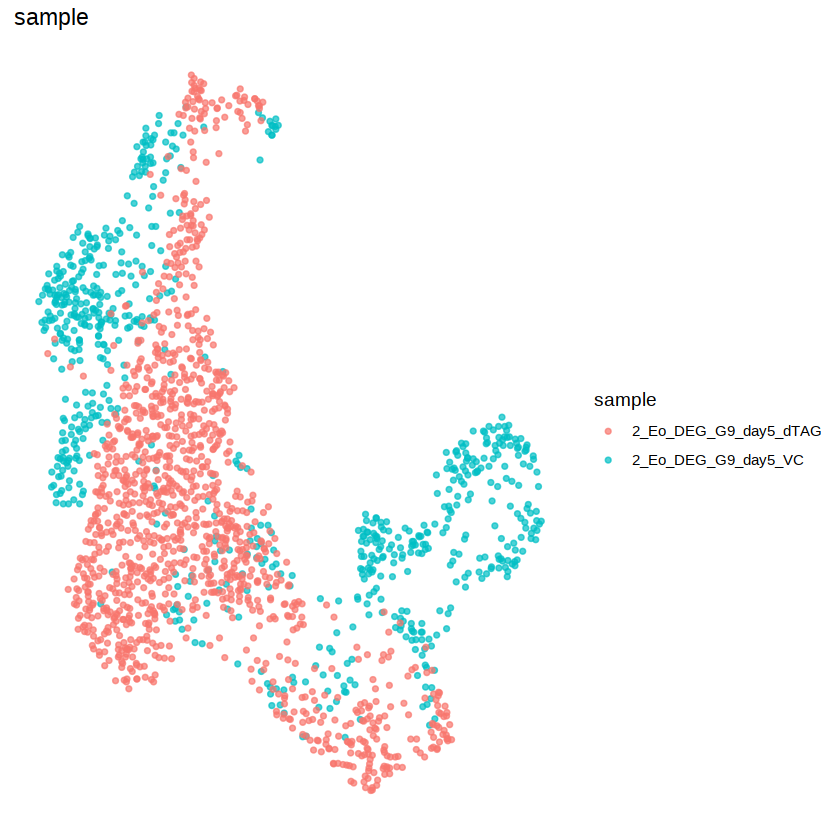

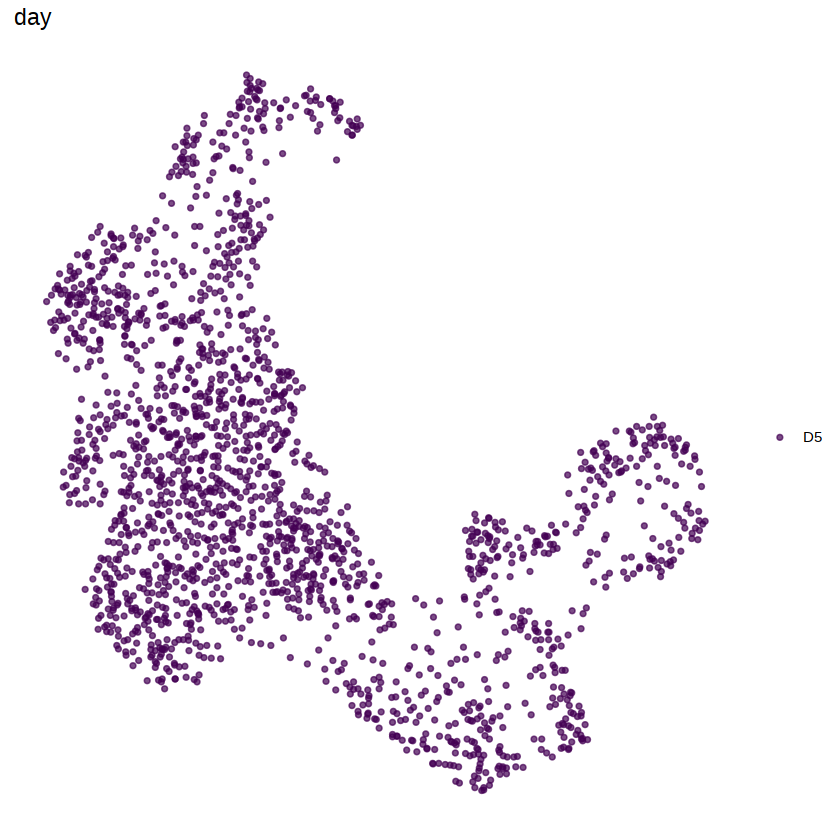

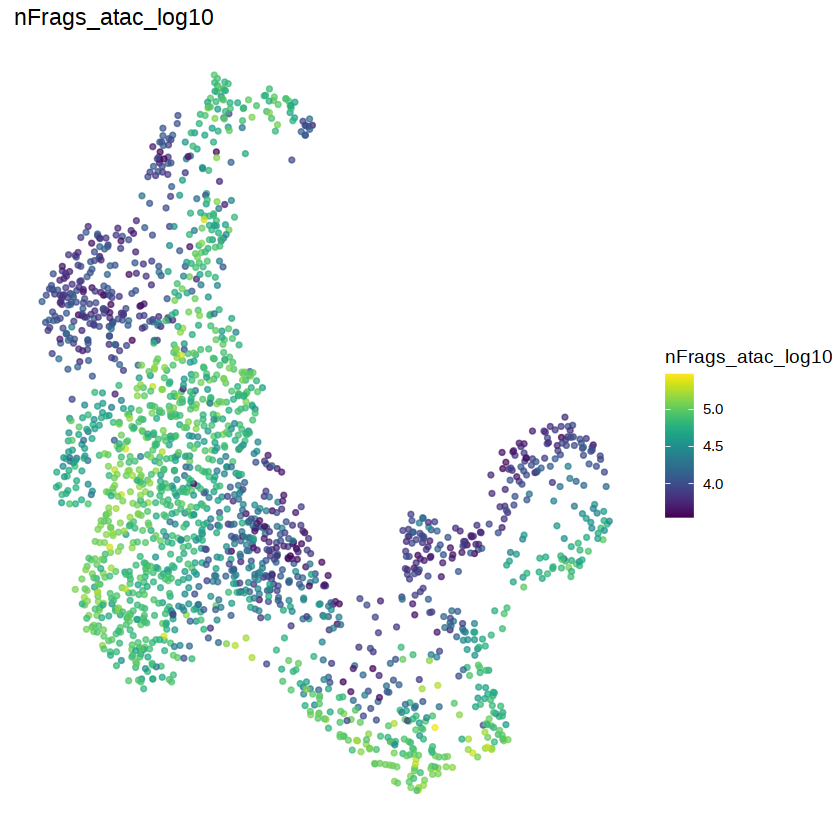

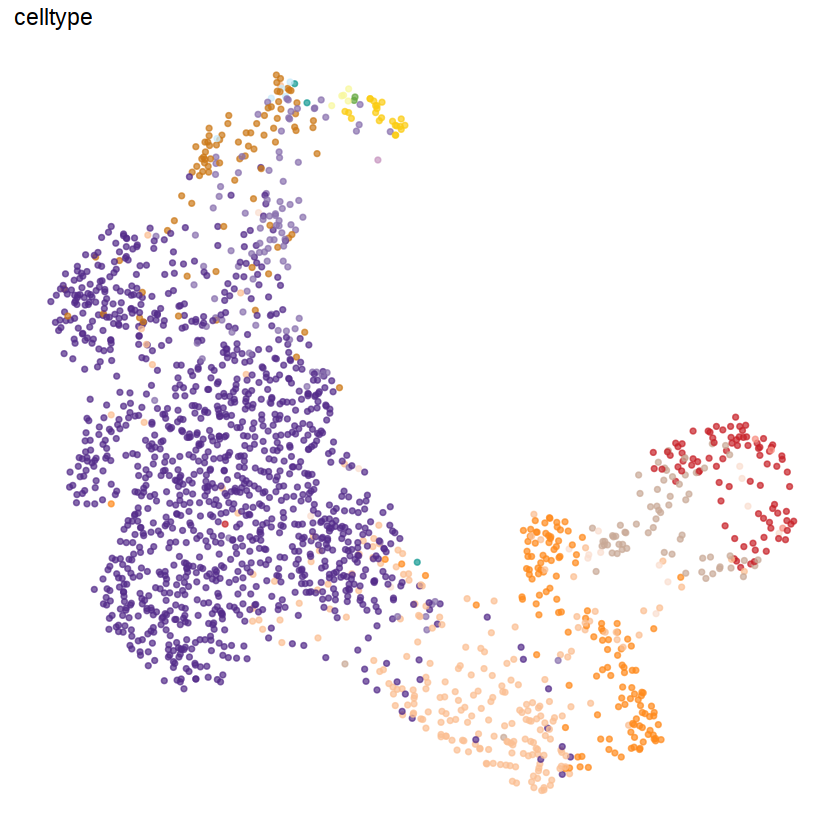

In [74]:
    for (k in args$colour_by) {
          library(viridis)
          
          # log10 large numeric values
          if (is.numeric(to.plot[[k]])) {
            if (max(to.plot[[k]],na.rm=T) - min(to.plot[[k]],na.rm=T) > 1000) {
              to.plot[[k]] <- log10(to.plot[[k]]+1)
              to.plot %>% setnames(k,paste0(k,"_log10")); k <- paste0(k,"_log10")
            }
          }

          p <- ggplot(to.plot, aes_string(x="umap1", y="umap2", col=k)) +
            geom_point(size=1, alpha = 0.7) +
            # ggrastr::geom_point_rast(size=1.5, shape=21, stroke=0.05) +  # DOES NOT WORK IN THE CLUSTER
            theme_classic() + ggtitle(k) +
            ggplot_theme_NoAxes()

          # Define colormap
          if (is.numeric(to.plot[[k]])) {
            p <- p + scale_color_viridis() 
          }

          if (grepl("celltype",k)) {
            p <- p + scale_color_manual(values=opts$celltype.colors) +
              theme(
                legend.position="none",
                legend.title=element_blank()
              )
          }

          if (grepl("day",k)) {
            p <- p + scale_color_viridis(discrete=TRUE) + 
              theme(
                legend.title=element_blank()
              )

          } 
        print(p)
        }

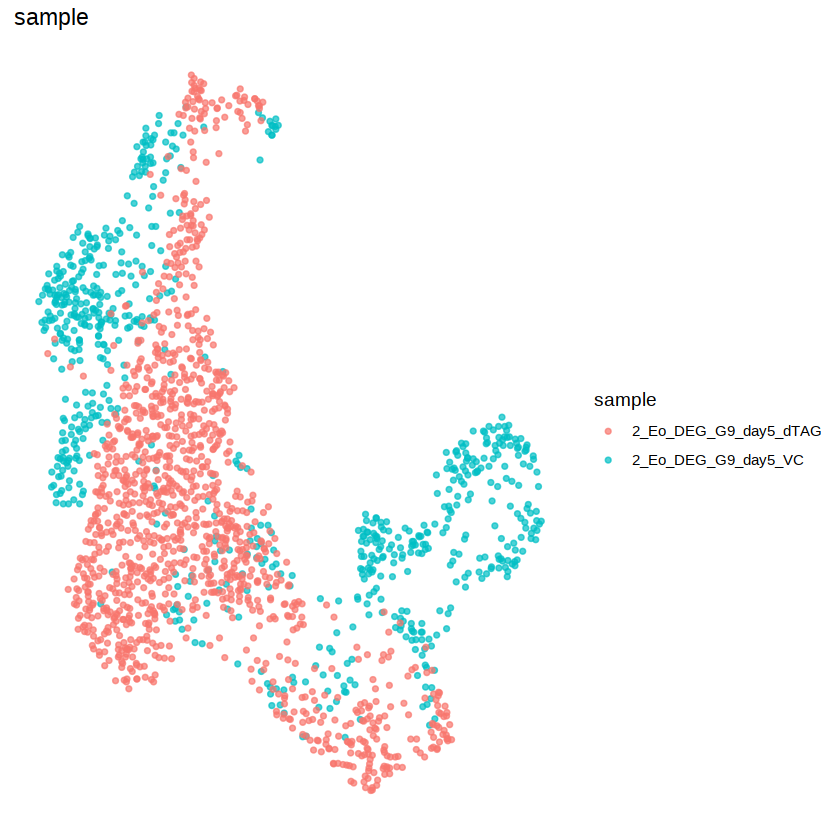

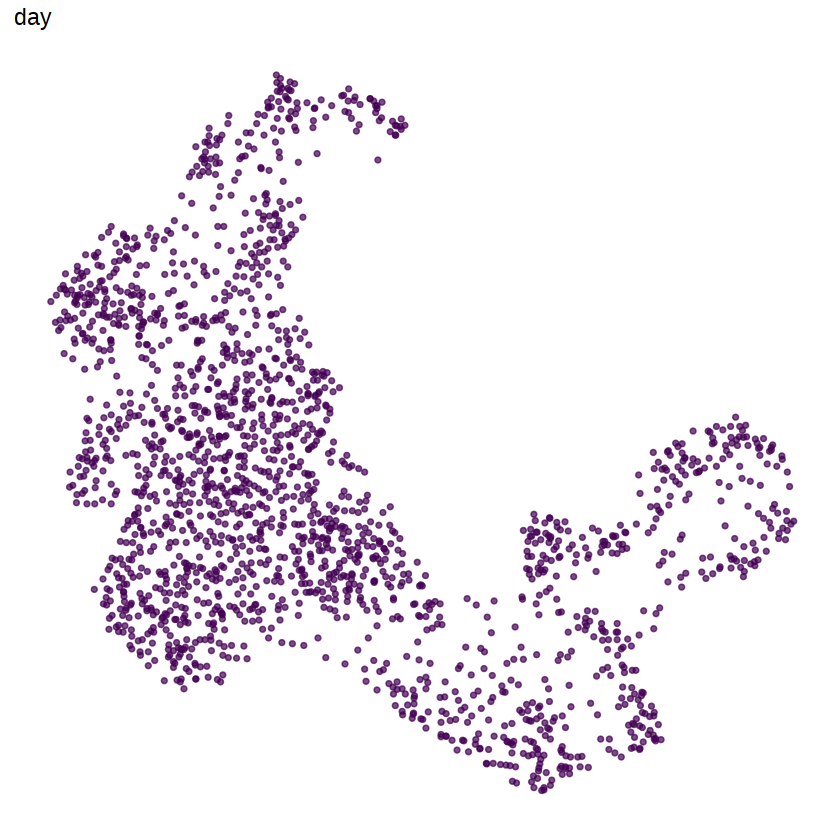

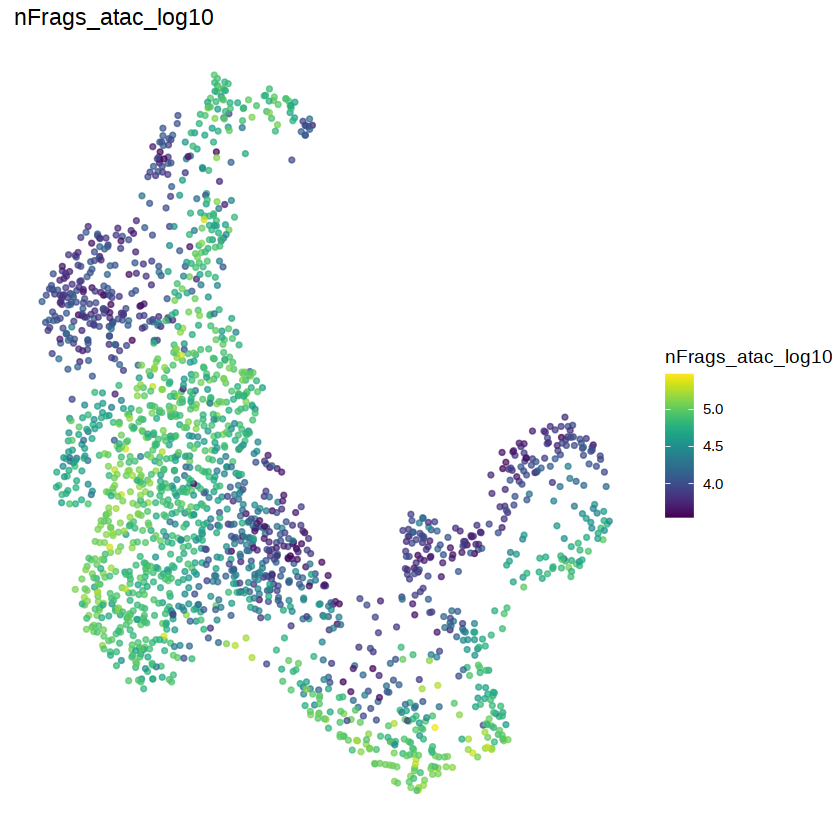

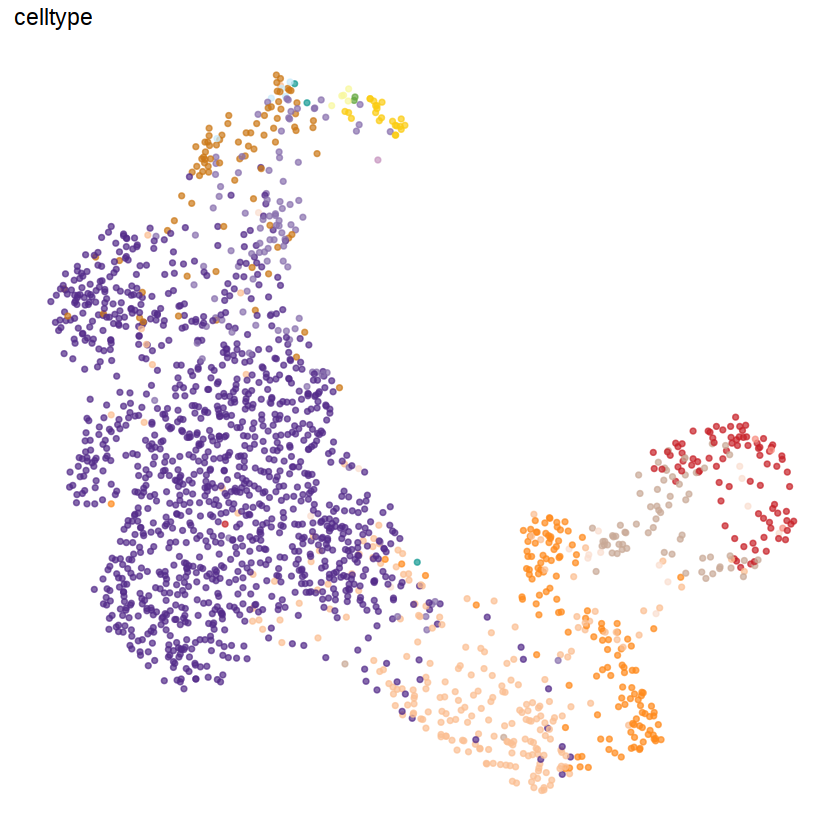

In [62]:
    # Plot
    to.plot <- umap.dt %>%
      merge(sample_metadata,by="cell")
        library(viridis)    

    for (k in args$colour_by) {

          # log10 large numeric values
          if (is.numeric(to.plot[[k]])) {
            if (max(to.plot[[k]],na.rm=T) - min(to.plot[[k]],na.rm=T) > 1000) {
              to.plot[[k]] <- log10(to.plot[[k]]+1)
              to.plot %>% setnames(k,paste0(k,"_log10")); k <- paste0(k,"_log10")
            }
          }

          p <- ggplot(to.plot, aes_string(x="umap1", y="umap2", col=k)) +
            geom_point(size=1, alpha = 0.7) +
            # ggrastr::geom_point_rast(size=1.5, shape=21, stroke=0.05) +  # DOES NOT WORK IN THE CLUSTER
            theme_classic() + ggtitle(k)+
            ggplot_theme_NoAxes()

          # Define colormap
          if (is.numeric(to.plot[[k]])) {
            p <- p + scale_color_viridis()
          }

          if (grepl("celltype",k)) {
            p <- p + scale_color_manual(values=opts$celltype.colors) +
              theme(
                legend.position="none",
                legend.title=element_blank()
              )
          }

          if (grepl("day",k)) {
            p <- p + scale_color_viridis(discrete=TRUE) + 
              theme(
                legend.position="none",
                legend.title=element_blank()
              )

          }
    print(p)
}

In [ ]:
here::i_am("atac/archR/dimensionality_reduction/cells/archR_dimensionality_reduction.R")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(ArchR))

######################
## Define arguments ##
######################

p <- ArgumentParser(description='')
p$add_argument('--metadata',        type="character",                               help='Cell metadata file')
p$add_argument('--matrix',          type="character",  default="PeakMatrix",   help='Matrix to use')
#p$add_argument('--samples',         type="character",                nargs='+',     help='Samples')
#p$add_argument('--stages',       type="character",  default="all",  nargs='+',  help='Stages to plot')
p$add_argument('--remove_ExE_cells',type="character",  default="False",  help='Remove ExE cells? ("True"/"False")')
p$add_argument('--nfeatures',       type="integer",    default=1000,               help='Number of features')
p$add_argument('--ndims',           type="integer",    default=30,                  help='Number of LSI dimensions')
p$add_argument('--batch_variable',  type="character",                               help='Metadata column to apply batch correction on')
p$add_argument('--batch_method',    type="character",  default="MNN",               help='Batch correctin method ("Harmony" or "MNN")')
p$add_argument('--n_neighbors',     type="integer",    default=30,   nargs='+',     help='(UMAP) Number of neighbours')
p$add_argument('--min_dist',        type="double",     default=0.3,  nargs='+',     help='(UMAP) Minimum distance')
p$add_argument('--colour_by',       type="character",  nargs='+',  help='Metadata columns to colour the UMAP by')
p$add_argument('--seed',            type="integer",    default=42,                  help='Random seed')
p$add_argument('--outdir',          type="character",                               help='Output directory')

args <- p$parse_args(commandArgs(TRUE))

## START TEST ##
# args <- list()
# args$metadata <- "/bi/group/reik/ricard/data/gastrulation_multiome_10x/results/atac/archR/qc/sample_metadata_after_qc.txt.gz"
# args$nfeatures <- 15000
# args$matrix <- "PeakMatrix"
# args$ndims <- 25
# args$seed <- 42
# args$n_neighbors <- 25
# args$min_dist <- 0.3
# args$colour_by <- c("sample","cluster")
# args$vars_to_regress <- c("nFeature_RNA","mitochondrial_percent_RNA")
# args$outdir <- "/bi/group/reik/ricard/data/gastrulation_multiome_10x/results/atac/archR/dimensionality_reduction"
## END TEST ##

if (args$remove_ExE_cells=="True") {
  args$remove_ExE_cells <- TRUE
} else if (args$remove_ExE_cells=="False") {
  args$remove_ExE_cells <- FALSE 
} else {
  stop('remove_ExE_cells should be "True" or "False"')
}

dir.create(sprintf("%s/%s/remove_ExE_cells_%s/batch_correction_%s/", 
      args$outdir, 
      args$matrix, 
      args$remove_ExE_cells, 
      paste(args$batch_variable,collapse="-")), recursive=TRUE, showWarnings =FALSE)

#####################
## Define settings ##
#####################

# Options
opts$lsi.iterations = 2
opts$lsi.cluster.resolution = 2

#if (args$stages[1]=="all") {
#  args$stages <- opts$stages
#} else {
#  stopifnot(args$stages%in%opts$stages)
#}


##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
  # .[pass_atacQC==TRUE & doublet_call==FALSE & sample%in%args$samples] %>%
  # .[nFrags_atac>=3500 & TSSEnrichment_atac>=9,pass_atacQC:=TRUE] %>% .[stage=="E8.7",stage:="E8.75"] %>%    # temporary
  .[pass_atacQC==TRUE & doublet_call==FALSE & sample%in%opts$samples] %>%
  .[,log_nFrags_atac:=log10(nFrags_atac)]
  
stopifnot(args$colour_by %in% colnames(sample_metadata))

if (args$remove_ExE_cells) {
  print("Removing ExE cells...")
  sample_metadata <- sample_metadata %>%
    .[!celltype%in%c("Visceral_endoderm","ExE_endoderm","ExE_ectoderm","Parietal_endoderm")]
}

table(sample_metadata$stage)
table(sample_metadata$celltype)

########################
## Load ArchR project ##
########################

source(here::here("atac/archR/load_archR_project.R"))

# Subset
ArchRProject.filt <- ArchRProject[sample_metadata$cell]
# ArchRProject.filt@sampleColData <- ArchRProject.filt@sampleColData[args$samples,,drop=F]

###################
## Sanity checks ##
###################

stopifnot(args$matrix %in% getAvailableMatrices(ArchRProject))

if (args$batch_variable!='None') {
  stopifnot(args$batch_variable%in%colnames(sample_metadata))
  if (length(unique(sample_metadata[[args$batch_variable]]))==1) {
    message(sprintf("There is a single level for %s, no batch correction applied",args$batch_variable))
    args$batch_variable <- NULL
  } else {
    library(batchelor)
  }
}

if (length(args$vars_to_regress)>0) {
  stopifnot(args$vars_to_regress%in%colnames(sample_metadata))
}

###########################
## Update ArchR metadata ##
###########################

sample_metadata.to.archr <- sample_metadata %>% 
  .[cell%in%rownames(ArchRProject.filt)] %>% setkey(cell) %>% .[rownames(ArchRProject.filt)] %>%
  as.data.frame() %>% tibble::column_to_rownames("cell")

stopifnot(all(rownames(sample_metadata.to.archr) == rownames(getCellColData(ArchRProject.filt))))
for (i in args$colour_by) {
  ArchRProject.filt <- addCellColData(
    ArchRProject.filt,
    data = sample_metadata.to.archr[[i]],
    name = i,
    cells = rownames(sample_metadata.to.archr),
    force = TRUE
  )
  print(table(getCellColData(ArchRProject.filt,i)[[1]]))
}


#######################
## Feature selection ##
#######################

# if (args$matrix=="PeakMatrix_filt") {
  
#   # Load peak variability estimates
#   peak.variability.dt <- fread(io$archR.peak.variability)
  
#   # Define highly variable peaks
#   peaks <- peak.variability.dt %>% 
#     .[,peak:=sub("_",":",peak)] %>% .[,peak:=sub("_","-",peak)] %>%
#     setorder(-variance_pseudobulk) %>% 
#     head(n=args$nfeatures) %>% 
#     .$peak
  
#   # Subset peaks in the ArchR object
#   names(ArchRProject.filt@peakSet) <- sprintf("%s:%s-%s",seqnames(ArchRProject.filt@peakSet), start(ArchRProject.filt@peakSet), end(ArchRProject.filt@peakSet))
#   ArchRProject.filt@peakSet[peaks,] <- ArchRProject.filt@peakSet[peaks,]
  
#   ArchRProject.filt <- addFeatureMatrix(
#     input = ArchRProject.filt,
#     features = ArchRProject.filt@peakSet,
#     matrixName = "PeakMatrix_filt",
#     binarize = TRUE
#   )
  
# }

###########################
## Latent Semantic Index ##
###########################

# Iterative LSI: two iterations
ArchRProject.filt <- addIterativeLSI(
  ArchRProj = ArchRProject.filt,
  useMatrix = args$matrix, 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = opts$lsi.iterations, 
   clusterParams = list(
    resolution = opts$lsi.cluster.resolution, 
    sampleCells = 10000, 
    maxClusters=NULL,
    n.start = 10
   ), 
  saveIterations = FALSE,
  varFeatures = args$nfeatures, 
  dimsToUse = 1:args$ndims,
  force = TRUE
)

# Correlation between latent dimensions and number of peaks
# cor(getReducedDims(ArchRProject.filt, "IterativeLSI"),ArchRProject.filt$nFrags)[,1] %>% abs %>% sort(decreasing = T)

############################
## LSI + Batch correction ##
############################
 outfile <- sprintf("%s/%s/remove_ExE_cells_%s/batch_correction_%s/lsi_nfeatures%d_dims%d.txt.gz", 
      args$outdir, 
      args$matrix, 
      args$remove_ExE_cells, 
      paste(args$batch_variable,collapse="-"), 
      args$nfeatures, 
      args$ndims)
      
if (args$batch_variable!='None') {
  print(sprintf("Applying %s batch correction for variable: %s", args$batch_method, args$batch_variable))
  #outfile <- sprintf("%s/lsi_%s_nfeatures%d_dims%d_%sbatchcorrection_by_%s.txt.gz",args$outdir, args$matrix, args$nfeatures, args$ndims, args$batch_method, paste(args$batch_variable,collapse="-"))
  
  # Harmony
  if (args$batch_method=="Harmony") {
    ArchRProject.filt <- addHarmony(
      ArchRProj = ArchRProject.filt,
      reducedDims = "IterativeLSI",
      name = "IterativeLSI_Harmony",
      groupBy = args$batch_variable,
      force = TRUE
    )
    lsi.dt <- getReducedDims(ArchRProject.filt, "IterativeLSI_Harmony") %>% round(3) %>% 
      as.data.table(keep.rownames = T) %>% setnames("rn","cell")

  } else {
    stop("Batch correction method not recognised")
  }

} else {
   
  lsi.dt <- getReducedDims(ArchRProject.filt, "IterativeLSI") %>% round(3) %>% 
    as.data.table(keep.rownames = T) %>% setnames("rn","cell")
}

# Save LSI coordinates
fwrite(lsi.dt, outfile)

##########
## UMAP ##
##########

# i <- args$n_neighbors[1]
# j <- args$min_dist[1]
for (i in args$n_neighbors) {
  for (j in args$min_dist) {
    
    # Define the latent space to run UMAP on
    if (args$batch_variable!='None') {
      if (args$batch_method=="Harmony") {
        dimred <- "IterativeLSI_Harmony"
      } else if  (args$batch_method=="MNN") {
        dimred <- "IterativeLSI_MNN"
      } else {
        stop("Batch correction method not recognised")
      }
    } else {
      dimred <- "IterativeLSI"
    }
    
    # Run UMAP
    ArchRProject.filt <- addUMAP(
      ArchRProj = ArchRProject.filt, 
      reducedDims = dimred,
      name = "UMAP",
      metric = "cosine",
      nNeighbors = i, 
      minDist = j, 
      seed = args$seed,
      saveModel = FALSE,
      force = TRUE
    )
    
    # Fetch UMAP coordinates
    umap.dt <- getEmbedding(ArchRProject.filt,"UMAP") %>%
      round(2) %>%
      as.data.table(keep.rownames = T) %>%
      setnames(c("cell","umap1","umap2"))
    
    # Save UMAP coordinates
    outfile <- sprintf("%s/%s/remove_ExE_cells_%s/batch_correction_%s/umap_nfeatures%d_dims%d_nneighbour%d_mindist%g.txt.gz", 
      args$outdir, 
      args$matrix, 
      args$remove_ExE_cells, 
      paste(args$batch_variable,collapse="-"), 
      args$nfeatures, 
      args$ndims,
      i,
      j)
  lsi.dt <- getReducedDims(ArchRProject.filt, "IterativeLSI") %>% round(3) %>% 
    as.data.table(keep.rownames = T) %>% setnames("rn","cell")
}
    fwrite(umap.dt, outfile)

    # Plot
    to.plot <- umap.dt %>%
      merge(sample_metadata,by="cell")
    
    for (k in args$colour_by) {

          # log10 large numeric values
          if (is.numeric(to.plot[[k]])) {
            if (max(to.plot[[k]],na.rm=T) - min(to.plot[[k]],na.rm=T) > 1000) {
              to.plot[[k]] <- log10(to.plot[[k]]+1)
              to.plot %>% setnames(k,paste0(k,"_log10")); k <- paste0(k,"_log10")
            }
          }

          p <- ggplot(to.plot, aes_string(x="umap1", y="umap2", col=k)) +
            geom_point(size=1, alpha = 0.7) +
            # ggrastr::geom_point_rast(size=1.5, shape=21, stroke=0.05) +  # DOES NOT WORK IN THE CLUSTER
            theme_classic() + ggtitle(k)+
            ggplot_theme_NoAxes()

          # Define colormap
          if (is.numeric(to.plot[[k]])) {
            p <- p + scale_color_viridis()
          }

          if (grepl("celltype",k)) {
            p <- p + scale_color_manual(values=opts$celltype.colors) +
              theme(
                legend.position="none",
                legend.title=element_blank()
              )
          }

          if (grepl("day",k)) {
            p <- p + scale_color_viridis(discrete=TRUE) + 
              theme(
                legend.position="none",
                legend.title=element_blank()
              )

          }
      # Save UMAP plot
      # outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_neigh%d_dist%s_%s.pdf",args$outdir, args$matrix, args$nfeatures, args$ndims, i, j, k)
          outfile <- sprintf("%s/%s/remove_ExE_cells_%s/batch_correction_%s/umap_nfeatures%d_dims%d_nneighbour%d_mindist%g_%s.pdf", 
      args$outdir, 
      args$matrix, 
      args$remove_ExE_cells, 
      paste(args$batch_variable,collapse="-"), 
      args$nfeatures, 
      args$ndims,
      i,
      j,
      k)
      pdf(outfile, width=7, height=5)
      print(p)
      dev.off()
    }
    
  }



In [ ]:

# i <- args$n_neighbors[1]
# j <- args$min_dist[1]
for (i in args$n_neighbors) {
  for (j in args$min_dist) {
    
    # Define the latent space to run UMAP on
    if (args$batch_variable!='None') {
      if (args$batch_method=="Harmony") {
        dimred <- "IterativeLSI_Harmony"
      } else if  (args$batch_method=="MNN") {
        dimred <- "IterativeLSI_MNN"
      } else {
        stop("Batch correction method not recognised")
      }
    } else {
      dimred <- "IterativeLSI"
    }
    
    # Run UMAP
    ArchRProject.filt <- addUMAP(
      ArchRProj = ArchRProject.filt, 
      reducedDims = dimred,
      name = "UMAP",
      metric = "cosine",
      nNeighbors = i, 
      minDist = j, 
      seed = args$seed,
      saveModel = FALSE,
      force = TRUE
    )
    
    # Fetch UMAP coordinates
    umap.dt <- getEmbedding(ArchRProject.filt,"UMAP") %>%
      round(2) %>%
      as.data.table(keep.rownames = T) %>%
      setnames(c("cell","umap1","umap2"))
    
    # Save UMAP coordinates
    outfile <- sprintf("%s/%s/remove_ExE_cells_%s/batch_correction_%s/umap_nfeatures%d_dims%d_nneighbour%d_mindist%f.txt.gz", 
      args$outdir, 
      args$matrix, 
      args$remove_ExE_cells, 
      paste(args$batch_variable,collapse="-"), 
      args$nfeatures, 
      args$ndims,
      i,
      j)
  lsi.dt <- getReducedDims(ArchRProject.filt, "IterativeLSI") %>% round(3) %>% 
    as.data.table(keep.rownames = T) %>% setnames("rn","cell")
}
    fwrite(umap.dt, outfile)

    # Plot
    to.plot <- umap.dt %>%
      merge(sample_metadata,by="cell")
    
    for (k in args$colour_by) {

      # log10 large numeric values
      if (is.numeric(to.plot[[k]])) {
        if (max(to.plot[[k]],na.rm=T) - min(to.plot[[k]],na.rm=T) > 1000) {
          to.plot[[k]] <- log10(to.plot[[k]]+1)
          to.plot %>% setnames(k,paste0(k,"_log10")); k <- paste0(k,"_log10")
        }
      }
      
      p <- ggplot(to.plot, aes_string(x="umap1", y="umap2", fill=k)) +
        geom_point(size=1, alpha = 0.7) +
        # ggrastr::geom_point_rast(size=1.5, shape=21, stroke=0.05) +  # DOES NOT WORK IN THE CLUSTER
        theme_classic() +
        ggplot_theme_NoAxes()
      
      # Define colormap
      if (is.numeric(to.plot[[j]])) {
        p <- p + scale_color_gradientn(colours = terrain.colors(10))
      }

      if (grepl("celltype",k)) {
        p <- p + scale_color_manual(values=opts$celltype.colors) +
          theme(
            legend.position="none",
            legend.title=element_blank()
          )
      }
      
      if (grepl("day",i)) {
        p <- p + scale_color_viridis(discrete=TRUE) + 
          theme(
            legend.position="none",
            legend.title=element_blank()
          )
      }
      # Save UMAP plot
      # outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_neigh%d_dist%s_%s.pdf",args$outdir, args$matrix, args$nfeatures, args$ndims, i, j, k)
          outfile <- sprintf("%s/%s/remove_ExE_cells_%s/batch_correction_%s/umap_nfeatures%d_dims%d_nneighbour%d_mindist%f_%s.pdf", 
      args$outdir, 
      args$matrix, 
      args$remove_ExE_cells, 
      paste(args$batch_variable,collapse="-"), 
      args$nfeatures, 
      args$ndims,
      i,
      j,
      k)
      outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_%s.pdf",args$outdir, args$matrix, args$nfeatures, args$ndims, k)
      pdf(outfile, width=7, height=5)
      print(p)
      dev.off()
    }
    
  }

